In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pathlib import Path

# ── Paths ──
EMB_DIR = Path('../embeddings')

EMB_PATH = EMB_DIR / 'one_random_walk/paper_grid/reprs_paper_grid_one_rw_1800_line000000_layer26.pt'

EMB_KEY = 'embeddings_last'
IDS_KEY = 'input_ids_last'

# ── Token-id → word mapping ──
ID_TO_WORD = {
    7160:  'sun',   2082:  'code',  14403: 'milk',  12224: 'bird',
    9462:  'sand',  1841:  'car',   19151: 'egg',   70368: 'mango',
    7033:  'math',  43516: 'opera', 3830:  'box',   3838:  'house',
    24149: 'apple', 11277: 'plane', 4641:  'phone', 7091:  'rock',
}
WORD_TO_TID = {w: t for t, w in ID_TO_WORD.items()}

# ── 4×4 grid layout ──
GRID = [
    ['apple', 'bird',  'car',   'egg'],
    ['house', 'milk',  'plane', 'opera'],
    ['box',   'sand',  'sun',   'mango'],
    ['rock',  'math',  'code',  'phone'],
]
WORD_TO_POS = {w: (r, c) for r, row in enumerate(GRID) for c, w in enumerate(row)}

# ── Shared plot style ──
ROW_COLORS = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
ROW_LABELS = [
    'Row 0: apple bird car egg',
    'Row 1: house milk plane opera',
    'Row 2: box sand sun mango',
    'Row 3: rock math code phone',
]

# ── Helper: grid edges between centroid pairs ──
def grid_edges(available_tids=None):
    """Return list of (tid1, tid2) for adjacent grid cells, optionally filtered."""
    edges = []
    for r in range(4):
        for c in range(4):
            t1 = WORD_TO_TID[GRID[r][c]]
            for rr, cc in [(r-1, c), (r+1, c), (r, c-1), (r, c+1)]:
                if 0 <= rr < 4 and 0 <= cc < 4:
                    t2 = WORD_TO_TID[GRID[rr][cc]]
                    if t1 < t2 and (available_tids is None or (t1 in available_tids and t2 in available_tids)):
                        edges.append((t1, t2))
    return edges

# ── Load the .pt file  ──
assert EMB_PATH.exists(), f'Missing: {EMB_PATH}'
_obj = torch.load(EMB_PATH, map_location='cpu', weights_only=False)
all_ids = _obj[IDS_KEY]
all_emb = _obj[EMB_KEY]
if all_ids.ndim == 2 and all_ids.shape[0] == 1:
    all_ids = all_ids[0]
if all_emb.ndim == 3 and all_emb.shape[0] == 1:
    all_emb = all_emb[0]
all_ids_np = all_ids.numpy()
all_emb_np = all_emb.float().numpy()
L_total = len(all_ids_np)

print(f'Loaded: {EMB_PATH.name}')
print(f'Sequence length: {L_total},  embedding dim: {all_emb_np.shape[1]}')


Loaded: reprs_paper_grid_one_rw_1800_line000000_layer26.pt
Sequence length: 500,  embedding dim: 4096


## Single random walk — Nw = 500, no batch averaging

One walk of length 1400, window = 500, but you can choose widow on which to average in "NW" variable. 


Window: 200 timesteps  (file length 500)
Unique tokens in window: 16


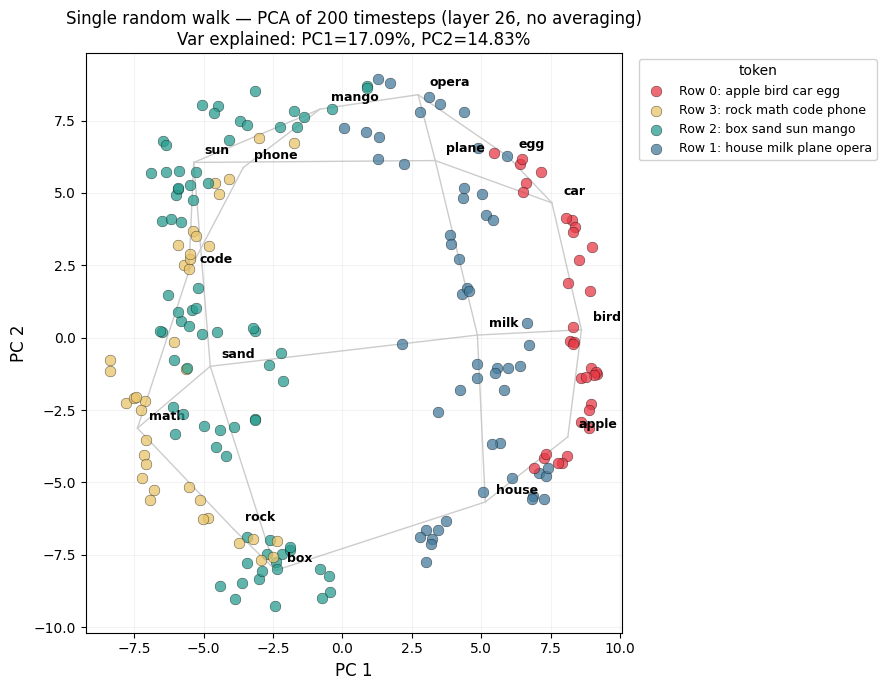

In [34]:
# ── Window the last NW timesteps ──
NW = 200
W = min(NW, L_total)

win_ids = all_ids_np[-W:]
win_emb = all_emb_np[-W:]

print(f'Window: {len(win_ids)} timesteps  (file length {L_total})')
print(f'Unique tokens in window: {len(np.unique(win_ids))}')

# ── PCA on windowed embeddings ──
pca_win = PCA(n_components=2, random_state=0)
Z_win = pca_win.fit_transform(win_emb)

# ── Per-token centroids ──
unique_win = np.unique(win_ids)
centroids = {int(t): Z_win[win_ids == t].mean(axis=0) for t in unique_win}

# ── Plot ──
fig, ax = plt.subplots(figsize=(9, 7))

for t1, t2 in grid_edges(available_tids=set(centroids)):
    c1, c2 = centroids[t1], centroids[t2]
    ax.plot([c1[0], c2[0]], [c1[1], c2[1]], color='#cccccc', lw=1, zorder=1)

legend_added = set()
for tid in unique_win:
    mask = win_ids == tid
    word = ID_TO_WORD.get(int(tid), str(tid))
    row_g, _ = WORD_TO_POS.get(word, (-1, -1))
    color = ROW_COLORS[row_g] if row_g >= 0 else 'grey'
    label = ROW_LABELS[row_g] if row_g >= 0 and row_g not in legend_added else None
    if row_g >= 0:
        legend_added.add(row_g)
    ax.scatter(Z_win[mask, 0], Z_win[mask, 1],
               s=60, alpha=0.75, color=color,
               edgecolors='k', linewidths=0.3, label=label, zorder=3)
    cx, cy = centroids[int(tid)]
    ax.annotate(word, (cx, cy), textcoords='offset points', xytext=(8, 6),
                fontsize=9, fontweight='bold')

ax.set_xlabel('PC 1', fontsize=12)
ax.set_ylabel('PC 2', fontsize=12)
ax.set_title(
    f'Single random walk — PCA of {len(win_ids)} timesteps (layer 26, no averaging)\n'
    f'Var explained: PC1={pca_win.explained_variance_ratio_[0]:.2%}, '
    f'PC2={pca_win.explained_variance_ratio_[1]:.2%}',
    fontsize=12,
)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9,
          framealpha=0.9, title='token')
ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()

## Single walk — last activation per token (no window, no averaging)

For each of the 16 grid tokens, take the embedding from the **last timestep**
where that token appeared in the sequence. This gives exactly one embedding
per token → H ∈ ℝ^{16 × d}, then PCA to 2D.

H_last shape: (16, 4096)  (one embedding per token)
Last-occurrence timesteps:
       car (id   1841):  t = 462
      code (id   2082):  t = 445
       box (id   3830):  t = 496
     house (id   3838):  t = 495
     phone (id   4641):  t = 426
      math (id   7033):  t = 498
      rock (id   7091):  t = 449
       sun (id   7160):  t = 474
      sand (id   9462):  t = 499
     plane (id  11277):  t = 493
      bird (id  12224):  t = 491
      milk (id  14403):  t = 494
       egg (id  19151):  t = 463
     apple (id  24149):  t = 490
     opera (id  43516):  t = 464
     mango (id  70368):  t = 465


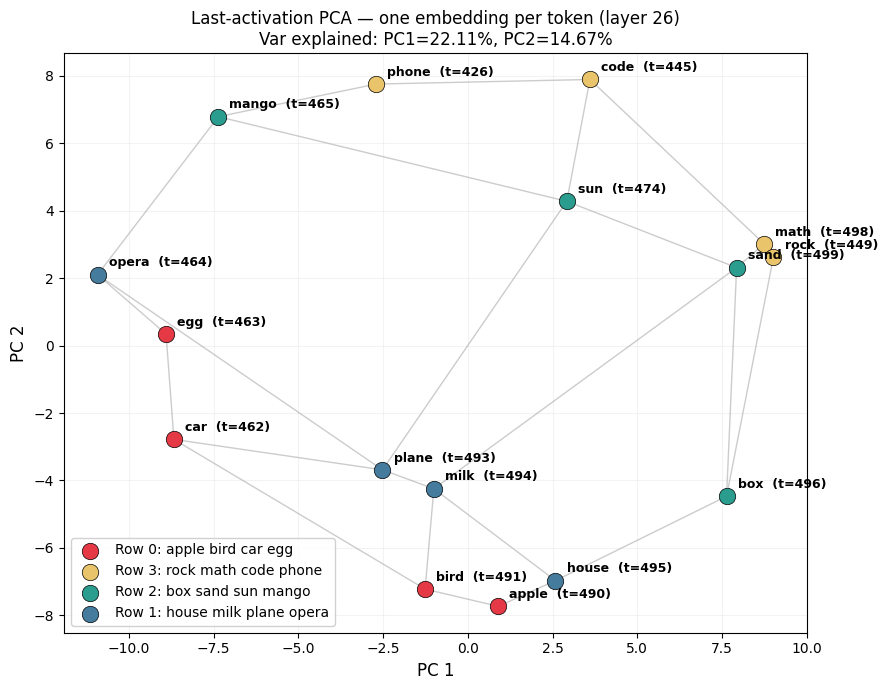

In [35]:
# ── For each token, pick the embedding at its LAST occurrence ──
unique_tids = sorted(ID_TO_WORD.keys())
H_last = np.zeros((len(unique_tids), all_emb_np.shape[1]), dtype=np.float32)
last_positions = {}

for i, tau in enumerate(unique_tids):
    positions = np.where(all_ids_np == tau)[0]
    assert len(positions) > 0, f'Token {tau} ({ID_TO_WORD[tau]}) never appears.'
    last_positions[tau] = int(positions[-1])
    H_last[i] = all_emb_np[positions[-1]]

print(f'H_last shape: {H_last.shape}  (one embedding per token)')
print('Last-occurrence timesteps:')
for tau in unique_tids:
    print(f'  {ID_TO_WORD[tau]:>8s} (id {tau:>6d}):  t = {last_positions[tau]}')

# ── PCA ──
pca_la = PCA(n_components=2, random_state=0)
Z_la = pca_la.fit_transform(H_last)

# ── Plot ──
tid_to_row = {tau: i for i, tau in enumerate(unique_tids)}

fig, ax = plt.subplots(figsize=(9, 7))

for t1, t2 in grid_edges():
    i1, i2 = tid_to_row[t1], tid_to_row[t2]
    ax.plot([Z_la[i1, 0], Z_la[i2, 0]], [Z_la[i1, 1], Z_la[i2, 1]],
            color='#cccccc', lw=1, zorder=1)

legend_added = set()
for i, tau in enumerate(unique_tids):
    word = ID_TO_WORD[tau]
    row_g, _ = WORD_TO_POS.get(word, (-1, -1))
    color = ROW_COLORS[row_g] if row_g >= 0 else 'grey'
    label = ROW_LABELS[row_g] if row_g >= 0 and row_g not in legend_added else None
    if row_g >= 0:
        legend_added.add(row_g)
    ax.scatter(Z_la[i, 0], Z_la[i, 1], s=140, c=color,
               edgecolors='k', linewidths=0.5, zorder=3, label=label)
    ax.annotate(f'{word}  (t={last_positions[tau]})',
                (Z_la[i, 0], Z_la[i, 1]),
                textcoords='offset points', xytext=(8, 6),
                fontsize=9, fontweight='bold')

ax.set_xlabel('PC 1', fontsize=12)
ax.set_ylabel('PC 2', fontsize=12)
ax.set_title(
    f'Last-activation PCA — one embedding per token (layer 26)\n'
    f'Var explained: PC1={pca_la.explained_variance_ratio_[0]:.2%}, '
    f'PC2={pca_la.explained_variance_ratio_[1]:.2%}',
    fontsize=12,
)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.15)
fig.tight_layout()
plt.show()